# Recolección de datos de tráfico — La Paz

Consulta la **Google Maps Distance Matrix API** para obtener tiempos de viaje con y sin tráfico en segmentos viales reales de La Paz. A partir de esa diferencia se calcula el `jam_factor` (0 = flujo libre, 10 = tráfico bloqueado).

**Requisitos previos:**
- Fase 2 completada: `data/raw/lapaz_edges.csv` y `data/raw/lapaz_network.gpkg` presentes
- `.env` con `GMAPS_API_KEY` válida

## 1. Imports y configuración

In [1]:
import os
import time
import googlemaps
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()

DATA_RAW = Path('../data/raw')
API_KEY = os.getenv('GMAPS_API_KEY')

if not API_KEY:
    raise ValueError('GMAPS_API_KEY no encontrada en .env')

client = googlemaps.Client(key=API_KEY)
print('Cliente Google Maps inicializado correctamente')

Cliente Google Maps inicializado correctamente


## 2. Selección de segmentos a muestrear

Se cargan las aristas de la red vial, se filtran por tipo de vía relevante para el tráfico vehicular y se extrae un sample estratificado de **250 segmentos**.

In [2]:
import geopandas as gpd

HIGHWAY_TYPES = ['primary', 'secondary', 'tertiary', 'trunk',
                 'primary_link', 'secondary_link', 'tertiary_link',
                 'trunk_link', 'residential', 'unclassified']

# Cargar nodos y aristas directamente desde el GeoPackage
nodes = gpd.read_file(DATA_RAW / 'lapaz_network.gpkg', layer='nodes')
edges = gpd.read_file(DATA_RAW / 'lapaz_network.gpkg', layer='edges')

def normalize_highway(hw):
    if isinstance(hw, list):
        return hw[0]
    return str(hw)

edges = edges.copy()
edges['highway_str'] = edges['highway'].apply(normalize_highway)
edges_filtradas = edges[edges['highway_str'].isin(HIGHWAY_TYPES)].copy()

print(f'Total de aristas en la red: {len(edges):,}')
print(f'Aristas vehiculares relevantes: {len(edges_filtradas):,}')
print('\nDistribución por tipo de vía:')
print(edges_filtradas['highway_str'].value_counts())

Total de aristas en la red: 20,438
Aristas vehiculares relevantes: 20,282

Distribución por tipo de vía:
highway_str
residential       15306
secondary          2073
tertiary           1270
primary             960
unclassified        309
trunk               130
secondary_link      122
primary_link         65
tertiary_link        45
trunk_link            2
Name: count, dtype: int64


In [3]:
N_SAMPLE = 250
np.random.seed(42)

conteos = edges_filtradas['highway_str'].value_counts()
proporciones = (conteos / conteos.sum() * N_SAMPLE).round().astype(int)
diff = N_SAMPLE - proporciones.sum()
proporciones.iloc[0] += diff

# nodes viene de gpd.read_file, osmid es columna (no índice)
node_coords = nodes.set_index('osmid')[['y', 'x']].rename(columns={'y': 'lat', 'x': 'lon'})

partes = []
for tipo, n in proporciones.items():
    if n > 0:
        subset = edges_filtradas[edges_filtradas['highway_str'] == tipo]
        n_real = min(n, len(subset))
        partes.append(subset.sample(n=n_real, random_state=42))

sample = pd.concat(partes).reset_index(drop=True)
sample['segment_id'] = sample.index
sample['lat_u'] = sample['u'].map(node_coords['lat'])
sample['lon_u'] = sample['u'].map(node_coords['lon'])
sample['lat_v'] = sample['v'].map(node_coords['lat'])
sample['lon_v'] = sample['v'].map(node_coords['lon'])
sample['lat']   = (sample['lat_u'] + sample['lat_v']) / 2
sample['lon']   = (sample['lon_u'] + sample['lon_v']) / 2
sample['length'] = sample['length'].apply(lambda x: x[0] if isinstance(x, list) else x)

# Quitar filas sin coordenadas válidas
sample = sample.dropna(subset=['lat_u', 'lon_u', 'lat_v', 'lon_v'])

cols = ['segment_id','u','v','lat_u','lon_u','lat_v','lon_v','highway_str','length','lat','lon']
sample_out = sample[cols].rename(columns={'highway_str': 'highway'})
sample_out.to_csv(DATA_RAW / 'sample_segments.csv', index=False)

print(f'Muestra guardada: {len(sample_out)} segmentos')
print(f'Archivo: data/raw/sample_segments.csv')
print('\nMuestra estratificada por tipo:')
print(sample_out['highway'].value_counts())
sample_out.head(5)

Muestra guardada: 250 segmentos
Archivo: data/raw/sample_segments.csv

Muestra estratificada por tipo:
highway
residential       186
secondary          26
tertiary           16
primary            12
unclassified        4
trunk               2
secondary_link      2
primary_link        1
tertiary_link       1
Name: count, dtype: int64


,segment_id,u,v,lat_u,lon_u,lat_v,lon_v,highway,length,lat,lon
0,0,2866782875,8957222011,-16.517557,-68.051942,-16.517585,-68.051242,residential,93.356595,-16.517571,-68.051592
1,1,2455499173,2455499173,-16.533906,-68.129547,-16.533906,-68.129547,residential,260.907870,-16.533906,-68.129547
2,2,1333236119,9643041207,-16.518678,-68.056227,-16.518629,-68.056693,residential,49.950192,-16.518653,-68.056460
3,3,1332075913,1332666584,-16.490407,-68.104755,-16.490324,-68.105150,residential,43.156481,-16.490366,-68.104952
4,4,2867899175,2867899177,-16.548138,-68.096509,-16.548952,-68.096031,residential,103.887536,-16.548545,-68.096270


## 3. Funciones de recolección

In [4]:
def get_traffic_flow(client, segments_df, departure_time=None):
    """Consulta Distance Matrix para cada segmento. departure_time=None usa datetime.now()."""
    if departure_time is None:
        departure_time = datetime.now()
    registros = []
    ts_label = departure_time
    total = len(segments_df)

    for i, row in segments_df.iterrows():
        try:
            result = client.distance_matrix(
                origins=[(row['lat_u'], row['lon_u'])],
                destinations=[(row['lat_v'], row['lon_v'])],
                mode='driving',
                departure_time=departure_time,
                traffic_model='best_guess'
            )
            elem = result['rows'][0]['elements'][0]
            if elem['status'] != 'OK':
                continue

            dur_libre = elem['duration']['value']
            dur_traf  = elem.get('duration_in_traffic', {}).get('value', dur_libre)
            dist_m    = elem['distance']['value']

            speed_free    = (dist_m / dur_libre * 3.6) if dur_libre > 0 else 0
            speed_current = (dist_m / dur_traf  * 3.6) if dur_traf  > 0 else 0
            jam = max(0.0, min(10.0, (dur_traf / dur_libre - 1) * 10)) if dur_libre > 0 else 0

            registros.append({
                'segment_id':    row['segment_id'],
                'street_name':   row.get('name', ''),
                'speed_current': round(speed_current, 2),
                'speed_free':    round(speed_free, 2),
                'jam_factor':    round(jam, 3),
                'timestamp':     ts_label,
                'lat':           row['lat'],
                'lon':           row['lon'],
                'highway':       row['highway'],
            })
        except Exception as e:
            # Retry una vez si es rate limit
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                time.sleep(2)
                try:
                    result = client.distance_matrix(
                        origins=[(row['lat_u'], row['lon_u'])],
                        destinations=[(row['lat_v'], row['lon_v'])],
                        mode='driving', departure_time=departure_time, traffic_model='best_guess'
                    )
                    elem = result['rows'][0]['elements'][0]
                    if elem['status'] == 'OK':
                        dur_libre = elem['duration']['value']
                        dur_traf  = elem.get('duration_in_traffic', {}).get('value', dur_libre)
                        dist_m    = elem['distance']['value']
                        speed_free    = (dist_m / dur_libre * 3.6) if dur_libre > 0 else 0
                        speed_current = (dist_m / dur_traf  * 3.6) if dur_traf  > 0 else 0
                        jam = max(0.0, min(10.0, (dur_traf / dur_libre - 1) * 10)) if dur_libre > 0 else 0
                        registros.append({'segment_id': row['segment_id'], 'street_name': row.get('name',''),
                            'speed_current': round(speed_current,2), 'speed_free': round(speed_free,2),
                            'jam_factor': round(jam,3), 'timestamp': ts_label,
                            'lat': row['lat'], 'lon': row['lon'], 'highway': row['highway']})
                except:
                    pass
            else:
                print(f'  [SKIP] seg {row["segment_id"]}: {e}')

        time.sleep(0.1)

    return pd.DataFrame(registros)


def collect_sample(client, segments_df, n_intervals=1):
    """Recolección en tiempo real (n_intervals rondas con pausa de 30s)."""
    archivos = []
    for i in range(n_intervals):
        print(f'\n[{i+1}/{n_intervals}] Intervalo {i+1} — {datetime.now().strftime("%H:%M:%S")}')
        df = get_traffic_flow(client, segments_df)
        if df.empty:
            print('  ADVERTENCIA: no se obtuvo ningún dato'); continue
        ts_str = datetime.now().strftime('%Y-%m-%d_%H-%M')
        path = DATA_RAW / f'traffic_{ts_str}.csv'
        df.to_csv(path, index=False)
        archivos.append(str(path))
        print(f'  Guardado: {path.name} — {len(df)} segmentos')
        if i < n_intervals - 1:
            print('  Esperando 30 segundos...'); time.sleep(30)
    print(f'\nRecolección completa. {len(archivos)} archivos generados.')
    return archivos


print('Funciones actualizadas: get_traffic_flow(departure_time), collect_sample, collect_historical (próxima celda)')

Funciones actualizadas: get_traffic_flow(departure_time), collect_sample, collect_historical (próxima celda)


## 4. Recolección histórica por modelo de Google

Usa `departure_time` con fechas futuras para obtener el modelo histórico de Google basado en meses de datos reales.
Consulta **3 tipos de día × 24 horas × 250 segmentos = 18,000 elementos**.

⚠️ Tiempo estimado: ~25 minutos. Cuota estimada: ~$18 USD del free trial.

In [5]:
import pytz
from datetime import datetime, timedelta

def collect_historical(client, segments_df, output_dir=None):
    """
    Recolecta datos históricos usando el modelo de tráfico de Google.
    Consulta 3 tipos de día × 24 horas y guarda traffic_TIPODÍA_HH.csv.
    """
    if output_dir is None:
        output_dir = DATA_RAW

    tz = pytz.timezone('America/La_Paz')
    today = datetime.now(tz)
    weekday = today.weekday()  # 0=lunes

    # Calcular próximos lunes, viernes, sábado (siempre en el futuro)
    def next_weekday(base, target_wd):
        days = (target_wd - base.weekday()) % 7 or 7
        return (base + timedelta(days=days)).replace(hour=0, minute=0, second=0, microsecond=0)

    day_bases = {
        'lunes':   next_weekday(today, 0),
        'viernes': next_weekday(today, 4),
        'sabado':  next_weekday(today, 5),
    }

    print('Fechas de referencia:')
    for nombre, dt in day_bases.items():
        print(f'  {nombre}: {dt.strftime("%Y-%m-%d %A")}')
    print(f'\nTotal consultas: {len(day_bases)} días × 24 horas × {len(segments_df)} segmentos'
          f' = {len(day_bases)*24*len(segments_df):,} elementos')
    print()

    archivos = []
    total_slots = len(day_bases) * 24
    slot_num = 0

    for dia_nombre, dia_base in day_bases.items():
        for hora in range(24):
            slot_num += 1
            departure_dt = dia_base.replace(hour=hora)

            # Saltar si el archivo ya existe
            fname = f'traffic_{dia_nombre}_{hora:02d}.csv'
            fpath = output_dir / fname
            if fpath.exists():
                print(f'[{slot_num}/{total_slots}] {dia_nombre} {hora:02d}:00 — ya existe, saltando')
                archivos.append(str(fpath))
                continue

            df = get_traffic_flow(client, segments_df, departure_time=departure_dt)

            if df.empty:
                print(f'[{slot_num}/{total_slots}] {dia_nombre} {hora:02d}:00 — SIN DATOS')
                continue

            df.to_csv(fpath, index=False)
            archivos.append(str(fpath))
            jam_mean = df['jam_factor'].mean()
            print(f'[{slot_num}/{total_slots}] {dia_nombre} {hora:02d}:00 — '
                  f'{len(df)} seg | jam_mean={jam_mean:.3f} | guardado: {fname}')

    print(f'\n✅ Recolección histórica completa: {len(archivos)} archivos generados.')
    return archivos


print('collect_historical() definida')

collect_historical() definida


In [6]:
# Cargar segmentos (si no están en memoria)
segments_df = pd.read_csv(DATA_RAW / 'sample_segments.csv')
print(f'Segmentos cargados: {len(segments_df)}')
print('Iniciando recolección histórica...')
print('Tiempo estimado: ~25 minutos\n')

archivos_historicos = collect_historical(client, segments_df)

Segmentos cargados: 250
Iniciando recolección histórica...
Tiempo estimado: ~25 minutos

Fechas de referencia:
  lunes: 2026-05-25 Monday
  viernes: 2026-05-22 Friday
  sabado: 2026-05-23 Saturday

Total consultas: 3 días × 24 horas × 250 segmentos = 18,000 elementos

[1/72] lunes 00:00 — ya existe, saltando
[2/72] lunes 01:00 — ya existe, saltando
[3/72] lunes 02:00 — ya existe, saltando
[4/72] lunes 03:00 — ya existe, saltando
[5/72] lunes 04:00 — ya existe, saltando
[6/72] lunes 05:00 — ya existe, saltando
[7/72] lunes 06:00 — ya existe, saltando
[8/72] lunes 07:00 — ya existe, saltando
[9/72] lunes 08:00 — ya existe, saltando
[10/72] lunes 09:00 — ya existe, saltando
[11/72] lunes 10:00 — ya existe, saltando
[12/72] lunes 11:00 — ya existe, saltando
[13/72] lunes 12:00 — ya existe, saltando
[14/72] lunes 13:00 — ya existe, saltando
[15/72] lunes 14:00 — ya existe, saltando
[16/72] lunes 15:00 — ya existe, saltando
[17/72] lunes 16:00 — ya existe, saltando
[18/72] lunes 17:00 — ya e

[24/72] lunes 23:00 — 250 seg | jam_mean=0.052 | guardado: traffic_lunes_23.csv


[25/72] viernes 00:00 — 250 seg | jam_mean=0.055 | guardado: traffic_viernes_00.csv


[26/72] viernes 01:00 — 250 seg | jam_mean=0.021 | guardado: traffic_viernes_01.csv


[27/72] viernes 02:00 — 250 seg | jam_mean=0.063 | guardado: traffic_viernes_02.csv


...

[68/72] sabado 19:00 — 250 seg | jam_mean=0.161 | guardado: traffic_sabado_19.csv


[69/72] sabado 20:00 — 250 seg | jam_mean=0.072 | guardado: traffic_sabado_20.csv


[70/72] sabado 21:00 — 250 seg | jam_mean=0.068 | guardado: traffic_sabado_21.csv


[71/72] sabado 22:00 — 250 seg | jam_mean=0.052 | guardado: traffic_sabado_22.csv


[72/72] sabado 23:00 — 250 seg | jam_mean=0.088 | guardado: traffic_sabado_23.csv

✅ Recolección histórica completa: 72 archivos generados.


## 5. Verificación del dataset histórico

Archivos históricos encontrados: 72 (esperado: 72)


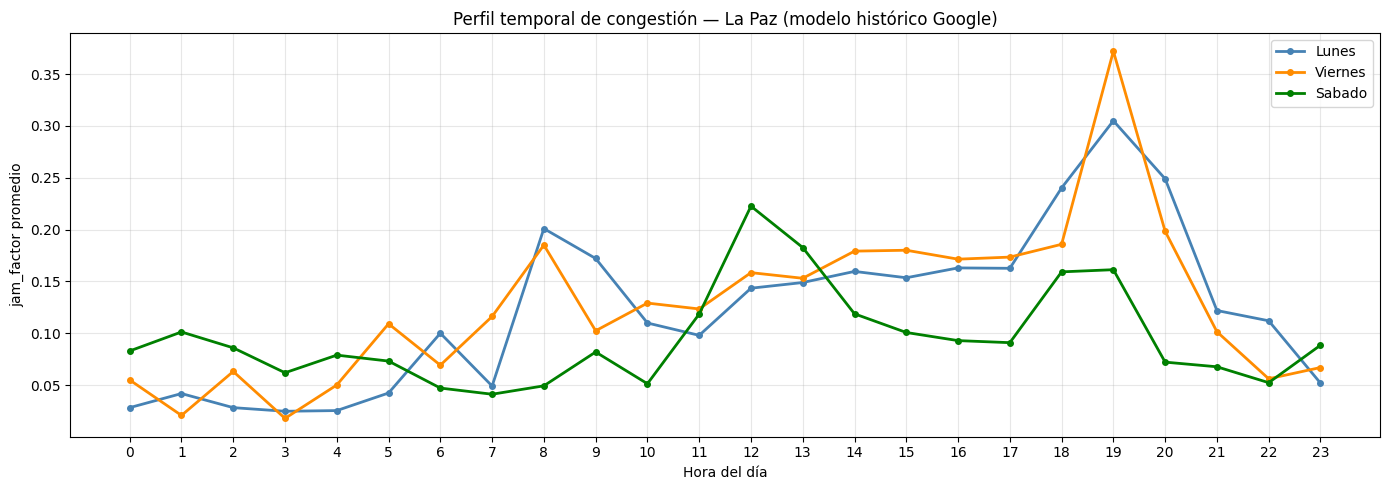

Gráfico guardado: data/raw/traffic_historical_profiles.png
lunes: jam rush (7-9h)=0.201 | jam noche (0-4h)=0.030 | patrón OK: True
viernes: jam rush (7-9h)=0.185 | jam noche (0-4h)=0.041 | patrón OK: True
sabado: jam rush (7-9h)=0.082 | jam noche (0-4h)=0.082 | patrón OK: False


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Cargar todos los archivos históricos
hist_files = sorted(DATA_RAW.glob('traffic_lunes_*.csv')) + \
             sorted(DATA_RAW.glob('traffic_viernes_*.csv')) + \
             sorted(DATA_RAW.glob('traffic_sabado_*.csv'))

print(f'Archivos históricos encontrados: {len(hist_files)} (esperado: 72)')

# Construir perfil temporal promedio por tipo de día
perfiles = {}
for dia in ['lunes', 'viernes', 'sabado']:
    jams_por_hora = []
    for h in range(24):
        fpath = DATA_RAW / f'traffic_{dia}_{h:02d}.csv'
        if fpath.exists():
            df = pd.read_csv(fpath)
            jams_por_hora.append(df['jam_factor'].mean())
        else:
            jams_por_hora.append(np.nan)
    perfiles[dia] = jams_por_hora

# Graficar perfiles temporales
fig, ax = plt.subplots(figsize=(14, 5))
horas = list(range(24))
colores = {'lunes': 'steelblue', 'viernes': 'darkorange', 'sabado': 'green'}
for dia, vals in perfiles.items():
    ax.plot(horas, vals, marker='o', label=dia.capitalize(),
            color=colores[dia], linewidth=2, markersize=4)

ax.set_xlabel('Hora del día')
ax.set_ylabel('jam_factor promedio')
ax.set_title('Perfil temporal de congestión — La Paz (modelo histórico Google)')
ax.set_xticks(horas)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_RAW / 'traffic_historical_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/raw/traffic_historical_profiles.png')

# Validar patrón esperado: hora punta mañana > medianoche
for dia, vals in perfiles.items():
    jam_rush = max(vals[7:10]) if not all(np.isnan(vals[7:10])) else 0
    jam_noche = np.nanmean(vals[0:5])
    print(f'{dia}: jam rush (7-9h)={jam_rush:.3f} | jam noche (0-4h)={jam_noche:.3f} | '
          f'patrón OK: {jam_rush > jam_noche}')

## 6. Resumen del dataset

Con los 72 archivos históricos generados el dataset cubre:
- **18,000 registros** (72 franjas × 250 segmentos)
- **3 tipos de día**: lunes, viernes, sábado
- **24 horas** por tipo de día
- Fuente: modelo histórico de Google Maps (promedio de meses de datos reales en La Paz)

Próximo paso: **FASE 5 — Preprocesamiento** (`notebooks/03_preprocesamiento.ipynb`)